In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from wordcloud import WordCloud
import re

In [ ]:
nltk.download('stopwords')

from nltk.corpus import stopwords

In [36]:
df = pd.read_excel('reviews_visualisation_ready.xlsx')

In [37]:
df = df.drop(['Unnamed: 0'], axis = 1)

In [38]:
df

,№,Сеть / формат,Адрес точки,Источник,Текст отзыва,Оценка,Дата,Город,clean_text,Ключевая миссия,Ключевая тема,Сентимент,Сильный позитив,Критичный негатив
0,1,Налету,"Москва, ул. Барклая, 6А, корп. 1",Yandex,"Удобный магазин, вкусный кофе и выпечка. Быстр...",5.0,2025-10-18,Москва,удобный магазин вкусный кофе и выпечка быс...,кофе / перекус,ассортимент,Позитивный,0,0
1,2,Налету,"Москва, ул. Барклая, 6А, корп. 1",Yandex,"Доставили сюда посылку 5post, было указано что...",2.0,2026-04-27,Москва,доставить сюда посылка 5post было указать чт...,базовые покупки,скорость,Негативный,0,0
2,3,Налету,"Москва, ул. Барклая, 6А, корп. 1",Yandex,"Расположение удобное, продавцы улыбчивые, прия...",3.0,2025-11-27,Москва,расположение удобный продавец улыбчивый пр...,кофе / перекус,качество еды,Нейтральный,0,0
3,4,Налету,"Москва, ул. Барклая, 6А, корп. 1",Yandex,"Нормальный магазин. Не очень большой выбор, но...",4.0,2026-01-02,Москва,нормальный магазин не очень большой выбор ...,базовые покупки,ассортимент,Позитивный,0,0
4,5,Налету,"Москва, ул. Барклая, 6А, корп. 1",Yandex,Кофе 3 в 1 80₽ и говорят такая цена. Через мес...,1.0,2025-11-30,Москва,кофе 3 в 1 80 и говорить такой цена через ...,кофе / перекус,цена,Негативный,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,253,Налету,NaN,Habr,"Кажется, сегодня ту Пятерочку настиг хабраэффе...",NaN,2021-02-24,NaN,казаться сегодня тот пятёрочка настигнуть ха...,базовые покупки,атмосфера / пространство,Нейтральный,0,0
253,254,Налету,NaN,Habr,"Где же мои глупые дети работать то будут, на п...",NaN,2021-03-01,NaN,где же мой глупый ребёнок работать то быть н...,базовые покупки,атмосфера / пространство,Негативный,0,0
254,255,Налету,NaN,Habr,"Ну, что заголовок кликбэйтный, это понятно :)\...",NaN,2021-03-08,NaN,ну что заголовок кликбэйтный это понятный ...,базовые покупки,цена,Нейтральный,0,0
255,256,Налету,NaN,Habr,Пользуюсь сервисом в одном из Зеленоградских П...,NaN,2021-05-05,NaN,пользоваться сервис в одном из зеленоградский ...,“забежать быстро”,ассортимент,Нейтральный,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   №                  257 non-null    int64         
 1   Сеть / формат      257 non-null    object        
 2   Адрес точки        168 non-null    object        
 3   Источник           257 non-null    object        
 4   Текст отзыва       257 non-null    object        
 5   Оценка             142 non-null    float64       
 6   Дата               257 non-null    datetime64[ns]
 7   Город              168 non-null    object        
 8   clean_text         257 non-null    object        
 9   Ключевая миссия    257 non-null    object        
 10  Ключевая тема      257 non-null    object        
 11  Сентимент          257 non-null    object        
 12  Сильный позитив    257 non-null    int64         
 13  Критичный негатив  257 non-null    int64         
dtypes: datetim

### 3.3 Сентимент

In [23]:
sent_ = {'Позитивный': 1, 'Нейтральный': 0, 'Негативный': -1}

def sent_to_numeric(text):
    text = str(text).lower()

    for string, numeric in sent_.items():
        text = re.sub(rf'\b{string.lower()}\b', str(numeric), text)

    return text

df['Сентимент_num'] = df['Сентимент'].apply(sent_to_numeric)

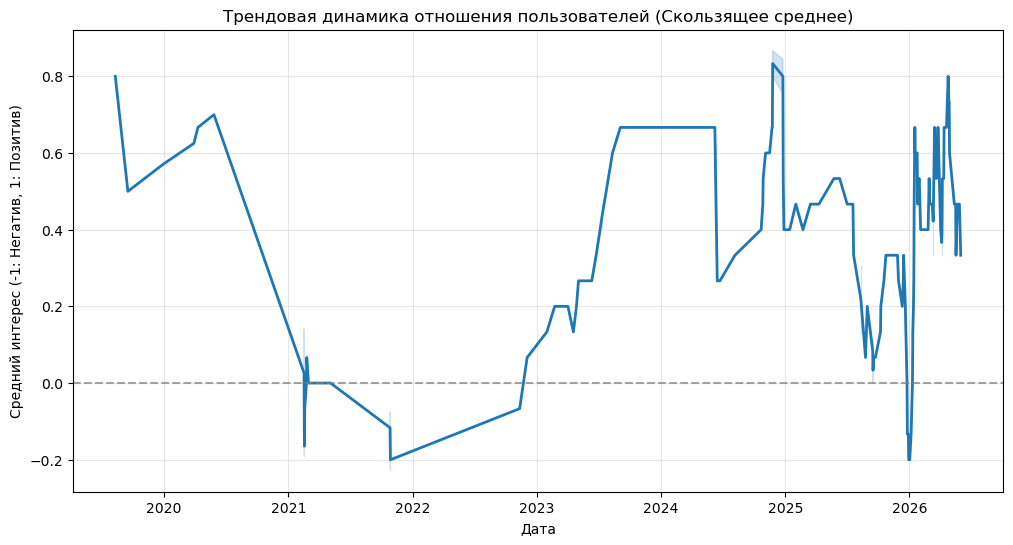

In [25]:
df_sorted = df.sort_values('Дата')
df_sorted['Скользящий сентимент'] = df_sorted['Сентимент_num'].rolling(window=15, min_periods=5).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sorted, x='Дата', y='Скользящий сентимент', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', alpha=0.7) # Линия баланса
plt.title('Трендовая динамика отношения пользователей (Скользящее среднее)')
plt.ylabel('Средний интерес (-1: Негатив, 1: Позитив)')
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
overall_sentiment = df['Сентимент'].value_counts(normalize=True).mul(100).reset_index(name = 'Распределение') 

overall_sentiment

,Сентимент,Распределение
0,Позитивный,46.303502
1,Нейтральный,35.797665
2,Негативный,17.898833


In [7]:
sentiment_by_network = pd.crosstab(df['Сеть / формат'], df['Сентимент'], normalize='index').mul(100)

sentiment_by_networkв

Сентимент,Негативный,Нейтральный,Позитивный
Сеть / формат,,,
Дикси Go,3.846154,69.230769,26.923077
Заряд от Магнита,25.490196,21.568627,52.941176
Налету,21.848739,50.420168,27.731092
Около,9.836066,4.918033,85.245902


In [8]:
wow_or_critical = df.groupby(df['Сеть / формат'])[['Сильный позитив', 'Критичный негатив']].mean().mul(100)

wow_or_critical

,Сильный позитив,Критичный негатив
Сеть / формат,,
Дикси Go,3.846154,0.000000
Заряд от Магнита,19.607843,11.764706
Налету,6.722689,5.882353
Около,29.508197,1.639344


In [8]:
wow_or_critical_abs = (df.groupby('Сеть / формат')[['Сильный позитив', 'Критичный негатив']].sum())

wow_or_critical_abs

,Сильный позитив,Критичный негатив
Сеть / формат,,
Дикси Go,1,0
Заряд от Магнита,10,6
Налету,8,7
Около,18,1


In [13]:
wow_or_critical_norm = (wow_or_critical_abs.div(wow_or_critical_abs.sum(axis=0), axis=1).mul(100))

wow_or_critical_norm

,Сильный позитив,Критичный негатив
Сеть / формат,,
Дикси Go,2.702703,0.000000
Заряд от Магнита,27.027027,42.857143
Налету,21.621622,50.000000
Около,48.648649,7.142857


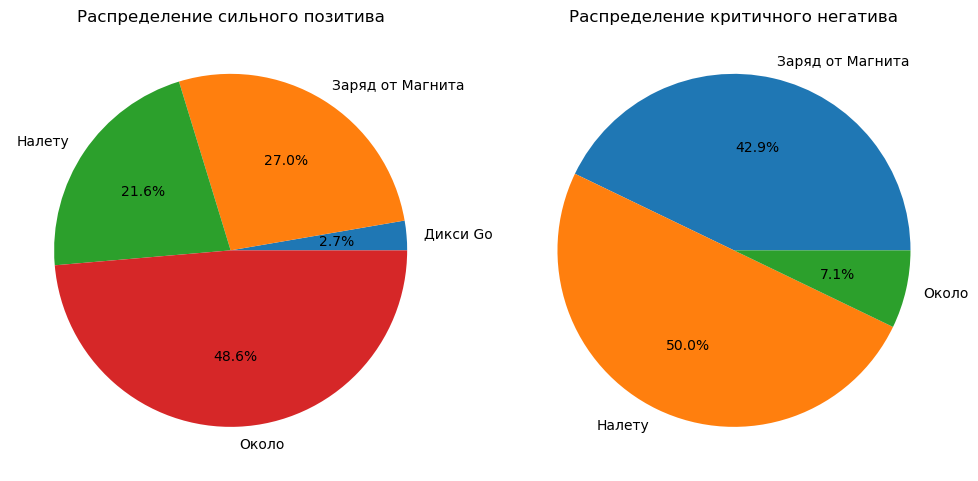

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

axes[0].pie(wow_or_critical_norm['Сильный позитив'], labels=wow_or_critical_norm.index, autopct='%1.1f%%')
axes[0].set_title('Распределение сильного позитива')

data = wow_or_critical_norm['Критичный негатив']
mask = data > 0

axes[1].pie(data[mask], labels=data[mask].index, autopct='%1.1f%%')
axes[1].set_title('Распределение критичного негатива')

plt.tight_layout()
plt.show()

### 3.4 Триггеры выбора

In [28]:
driver_of_positive = df[df['Сентимент']=='Позитивный']['Ключевая тема'].value_counts(normalize = True).mul(100)

driver_of_positive

Ключевая тема
атмосфера / пространство    34.453782
ассортимент                 27.731092
качество еды                17.647059
сервис                      13.445378
цена                         5.042017
скорость                     1.680672
Name: proportion, dtype: float64

In [48]:
positive_samples = df[df['Сентимент'] == 'Позитивный']['Текст отзыва'].head(5).tolist()

for i, text in enumerate(positive_samples, 1):
    print(f'{i}. {text}')

1. Удобный магазин, вкусный кофе и выпечка. Быстро можно все взять и оплатить на кассе самообслуживания, есть столики посидеть. Большой выбор лапши и рамена
2. Нормальный магазин. Не очень большой выбор, но базовое все есть. Чисто, расставлено все аккуратно
3. Вежливые сотрудники
4. Чисто. Быстро.
5. Уютный магазин, где есть все самое необходимое. Особенно понравилось наличие зоны кафе, где можно самостоятельно заварить лапшу или разогреть уже готовую еду, выбор которой в магазине достаточно большой. Еще здесь вкусная пицца, бургеры и хот-доги. Можно перекусить в кафе или взять с собой.


In [29]:
driver_of_negative= df[df['Сентимент']=='Негативный']['Ключевая тема'].value_counts(normalize = True).mul(100)

driver_of_negative

Ключевая тема
атмосфера / пространство    36.956522
скорость                    19.565217
ассортимент                 19.565217
цена                        10.869565
сервис                       8.695652
качество еды                 4.347826
Name: proportion, dtype: float64

In [49]:
negative_samples = df[df['Сентимент'] == 'Негативный']['Текст отзыва'].head(5).tolist()

for i, text in enumerate(negative_samples, 1):
    print(f'{i}. {text}')

1. Доставили сюда посылку 5post, было указано что на кассу Пятерочки. Ходил кругами, искал эту Пятерочку. Звонил в тех поддержку, говорят Пятерочка есть, мы по карте видим… в итоге оказывается что посылка в этом магазине. Вы бы хоть наклейку на дверь наклеили 5post. И обновите данные и название пункта выдачи в смс сообщениях.
2. Кофе 3 в 1 80₽ и говорят такая цена. Через месяц исправились
3. Никогда продавцов нет на месте, невозможно получить посылки 5post!
4. Сет в магазине не ловит, что явно отталкивает покупателя. Оплатить по сбп невозможно. На места для сидения можно сидушки положить, очень холодно на плитке сидеть
5. Отвратительно. Сотрудники курят у магазина, на просьбу не курить- игнорируют. Женщина рыжая несколько раз останавливала у выхода в магазин поверить не взяла ли что то, даже не извинилась


In [14]:
driver_of_neutral = df[df['Сентимент'] == 'Нейтральный']['Ключевая тема'].value_counts(normalize=True).mul(100)

driver_of_neutral    

Ключевая тема
атмосфера / пространство    48.913043
ассортимент                 16.304348
сервис                      15.217391
цена                         8.695652
качество еды                 7.608696
скорость                     3.260870
Name: proportion, dtype: float64

In [51]:
neutral_samples = df[df['Сентимент'] == 'Нейтральный']['Текст отзыва'].head(3).tolist()
for i, text in enumerate(neutral_samples, 1):
    print(f'{i}. {text}')

1. Расположение удобное, продавцы улыбчивые, приятные люди, теперь о минусах кофе машина , из доступных 8 напитков доступно только 3, выпечку не берите, два раза брали оба раза начинка тухлая
2. Хороший, новый, чистый магазин. Мало людей, что делает покупки приятнее. Только цены удручают. Вода 0,4 стоит 69 рублей, так как в магазине, который у Кремля стоит на рубль дороже.
3. Очень не плохо для магазина у дома и есть, там всё нужное, чтобы не ехать в большие центры.

Чуть грязно, но честно это не к ним претензии, тем более сотрудники…


In [16]:
theme_sentiment = pd.crosstab(df['Ключевая тема'], df['Сентимент'], normalize='index') * 100
theme_sentiment

Сентимент,Негативный,Нейтральный,Позитивный
Ключевая тема,,,
ассортимент,15.789474,26.315789,57.894737
атмосфера / пространство,16.504854,43.689320,39.805825
качество еды,6.666667,23.333333,70.000000
сервис,11.764706,41.176471,47.058824
скорость,64.285714,21.428571,14.285714
цена,26.315789,42.105263,31.578947


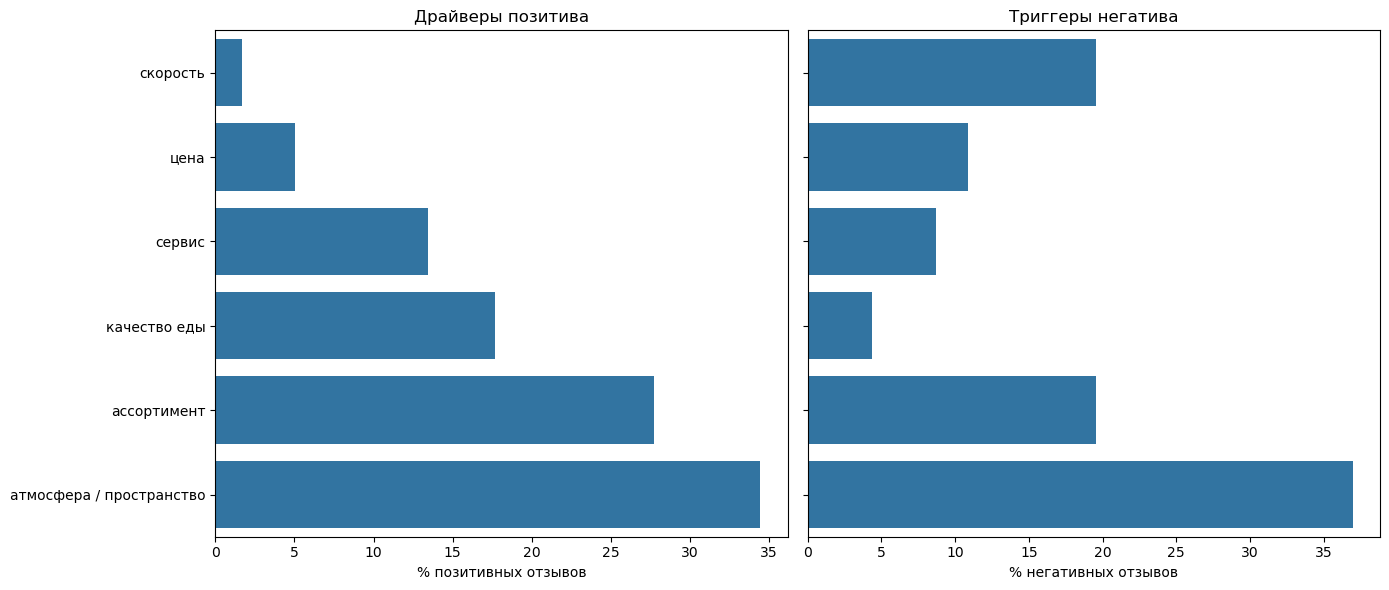

In [31]:
pos = driver_of_positive.sort_values(ascending=True)
neg = driver_of_negative.sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

sns.barplot(x=pos.values, y=pos.index, ax=axes[0])
sns.barplot(x=neg.values, y=neg.index, ax=axes[1])

axes[0].set_title('Драйверы позитива')
axes[0].set_xlabel('% позитивных отзывов')
axes[0].set_ylabel('')
axes[1].set_title('Триггеры негатива')
axes[1].set_xlabel('% негативных отзывов')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [47]:
suggestions = 'добав|хотелось бы|надо|нужно|сделай|расшир|улучш|не хват|постав'

product_suggestions = df[(df['Ключевая тема'] == 'ассортимент') & (df['clean_text'].str.contains(suggestions, case=False, na=False))]['Текст отзыва'].head(10).tolist()

for text in product_suggestions:
    print(f'- {text}')

print('\n')
service_or_format_suggestions = df[(df['Ключевая тема'].isin(['сервис', 'атмосфера / пространство', 'атмосфера / пространство', 'скорость'])) & (df['Текст отзыва'].str.contains(suggestions, case=False, na=False))]['Текст отзыва'].head(10).tolist()

for text in service_or_format_suggestions:
    print(f'- {text}')

- Магазин норм, но кому можно написать по ассортименту? Мне много чего не хватает! Например зачем ставить столько крепкого алкоголя, сократите в 10 раз.
Если позиционируете себя а-ля взять и съесть там, то почему для…
- Магазин маленький, но аккуратный,все продавцы вежливые, всегда расскажут о акциях, помогут в выборе. Захожу каждое утро за вкусным круассаном и кофе. Большой плюс скоро добавиться касса самообслуживания
- "ультрамалый" - это когда денег на нормальную аренду не хватает, или что? 90 квадратов - это же как моя гостиная. И ассортимент урезали втрое, зато гордо называют это "самыми востребованными товарами"
- Все очень круто, я не понял одного. ЗАЧЕМ? В чем юзеркейс? Освоены технологии, отлично. Интел реалсенс это реально крутая технология, сам играюсь, правда говорят ее задеприкейтят скооро.  Возможно потрачены некие деньги, хорошо. Айти отдел показал свою нужность, кто то отчитался, провел презентацию, вот пост на хабр есть, превосходно. Покупателю зачем?! Я вот предпочита

## 3.5 TF - IDF

In [39]:
russian_stopwords = stopwords.words('russian')
    
possible_problem = {
    'магазин', 'магазине', 'магазина', 'формат', 'формата', 
    'это', 'налету', 'заряд', 'дикси', 'около', 'сити',
    'очень', 'просто', 'вообще', 'целом', 'свой', 'который'}

real_stopwords = russian_stopwords + list(possible_problem)

positive_text = ' '.join(df[df['Сентимент'] == 'Позитивный']['clean_text'].astype(str))
negative_text = ' '.join(df[df['Сентимент'] == 'Негативный']['clean_text'].astype(str))

vectorizer = CountVectorizer(stop_words=real_stopwords, ngram_range=(1, 2))

X = vectorizer.fit_transform([positive_text, negative_text])

freq_df = pd.DataFrame(X.toarray().T, index=vectorizer.get_feature_names_out(), columns=['Позитивный', 'Негативный'])

In [40]:
freq_df['Позитивный'].sort_values(ascending=False).head(10)

хороший      40
отличный     18
сотрудник    16
еда          14
место        14
товар        14
продавец     14
большой      14
вежливый     14
выбор        14
Name: Позитивный, dtype: int64

In [41]:
freq_df['Негативный'].sort_values(ascending=False).head(10)

говорить      10
работать       9
касса          9
человек        8
дверь          8
заходить       7
приложение     7
цена           6
клиент         6
карта          6
Name: Негативный, dtype: int64

#### Сравнение по форматам

In [42]:
pos_neg = df[df['Сентимент'].isin(['Позитивный', 'Негативный'])]
docs = (pos_neg.groupby(['Сеть / формат', 'Сентимент'])['clean_text'].agg(' '.join))

vectorizer = TfidfVectorizer(stop_words=real_stopwords, ngram_range=(2,2))

tfidf = vectorizer.fit_transform(docs)

tfidf_df = pd.DataFrame(tfidf.toarray(), index=docs.index, columns=vectorizer.get_feature_names_out())

for group in tfidf_df.index:
    print(f'\n ГРУППА: {' | '.join(group).upper()}')

    top_words = tfidf_df.loc[group].nlargest(10)

    for word, score in top_words.items():
        print(f'{word:<25} ({score:.3f})')


 ГРУППА: ДИКСИ GO | НЕГАТИВНЫЙ
автомат время             (0.302)
вовсе сломаются           (0.302)
время работать            (0.302)
кофейный автомат          (0.302)
мыть обслуживать          (0.302)
обслуживать вовсе         (0.302)
повесить табличка         (0.302)
работать мыть             (0.302)
работать проходить        (0.302)
сломаются повесить        (0.302)

 ГРУППА: ДИКСИ GO | ПОЗИТИВНЫЙ
2020 год                  (0.123)
dicksee однажды           (0.123)
love dicksee              (0.123)
автомобиль котором        (0.123)
американский кантри       (0.123)
быстрый покупка           (0.123)
востребованную продукция  (0.123)
выйти прогруляться        (0.123)
высота ебать              (0.123)
гастроль россия           (0.123)

 ГРУППА: ЗАРЯД ОТ МАГНИТА | НЕГАТИВНЫЙ
04 26                     (0.132)
сюда заходить             (0.132)
срок годность             (0.095)
касса самообслуживание    (0.083)
05 04                     (0.066)
11 день                   (0.066)
25 04       

## 3.6 Юз кейс

In [14]:
use_case = pd.crosstab(df['Сеть / формат'], df['Ключевая миссия'], normalize = 'index').mul(100)

In [15]:
use_case

Ключевая миссия,базовые покупки,готовая еда,использование сервиса / приложения,кофе / перекус,“забежать быстро”
Сеть / формат,,,,,
Дикси Go,80.769231,7.692308,3.846154,3.846154,3.846154
Заряд от Магнита,58.823529,21.568627,0.000000,15.686275,3.921569
Налету,53.781513,10.084034,14.285714,15.966387,5.882353
Около,88.524590,1.639344,3.278689,3.278689,3.278689


In [16]:
use_case = use_case.reset_index().melt(id_vars='Сеть / формат', var_name='Ключевая миссия', value_name='Доля')

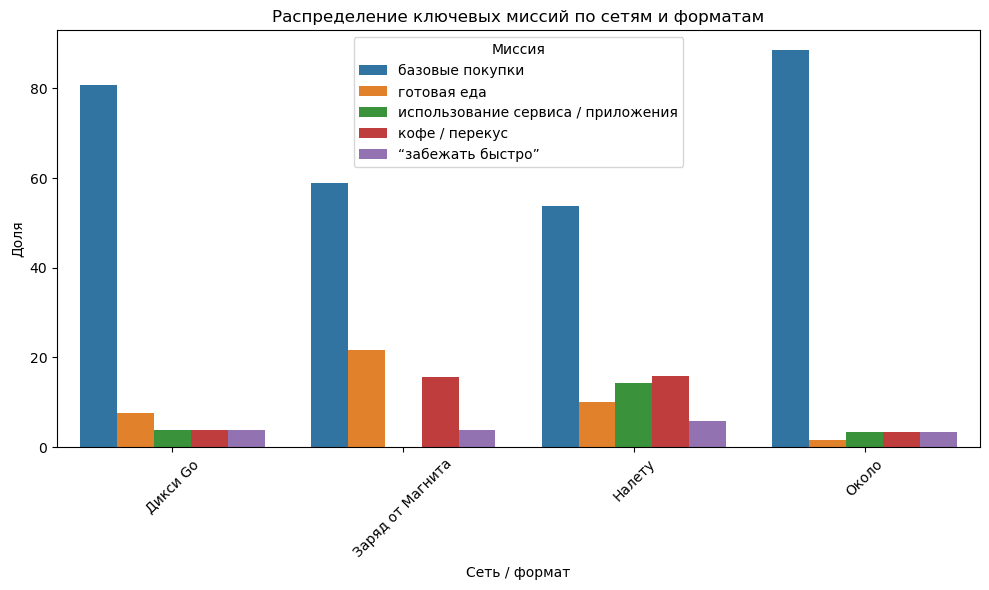

In [23]:

plt.figure(figsize=(10, 6))
sns.barplot(data=use_case, x='Сеть / формат', y='Доля', hue='Ключевая миссия')
plt.title('Распределение ключевых миссий по сетям и форматам')
plt.xticks(rotation=45)
plt.legend(title='Миссия')
plt.tight_layout()
plt.show()

## 3.7 Портреты потребителей

In [35]:
print(df['Ключевая миссия'].value_counts())

Ключевая миссия
базовые покупки                       169
кофе / перекус                         30
готовая еда                            26
использование сервиса / приложения     20
“забежать быстро”                      12
Name: count, dtype: int64


In [36]:
print(df['Ключевая тема'].value_counts())

Ключевая тема
атмосфера / пространство    103
ассортимент                  57
сервис                       34
качество еды                 30
цена                         19
скорость                     14
Name: count, dtype: int64


In [37]:
print(df['Сеть / формат'].value_counts())

Сеть / формат
Налету              119
Около                61
Заряд от Магнита     51
Дикси Go             26
Name: count, dtype: int64


In [43]:
subdf_comfort = df.loc[(df['Ключевая миссия'] == 'базовые покупки') & (df['Ключевая тема'] == 'атмосфера / пространство'), ['Сеть / формат', 'Текст отзыва', 'Оценка']]
subdf_comfort.to_excel('segment_1_comfort_buying.xlsx', index=False)

subdf_assortment = df.loc[(df['Ключевая миссия'] == 'базовые покупки') & (df['Ключевая тема'] == 'ассортимент'), ['Сеть / формат', 'Текст отзыва', 'Оценка']]
subdf_assortment.to_excel('segment_2_assortment.xlsx', index=False)

subdf_cafe = df.loc[(df['Ключевая миссия'] == 'кофе / перекус') & (df['Ключевая тема'] == 'качество еды'), ['Сеть / формат', 'Текст отзыва', 'Оценка']]
subdf_cafe.to_excel('segment_3_coffee_cafe.xlsx', index=False)

## 3.8 Визуализации

### распределение сентимента (по форматам)

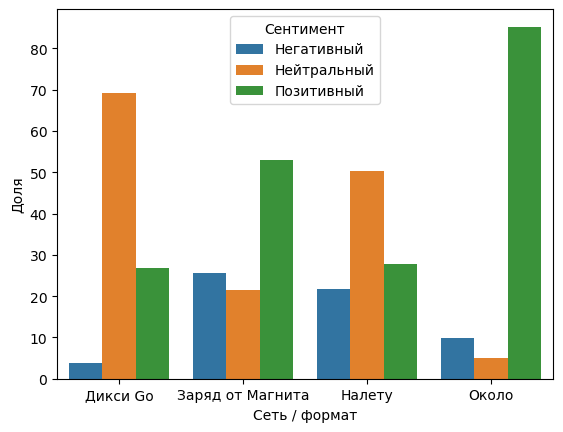

In [25]:
sbn_df = sentiment_by_network.reset_index().melt(id_vars='Сеть / формат', var_name='Сентимент', value_name='Доля')

sns.barplot(data=sbn_df, x='Сеть / формат', y='Доля', hue='Сентимент')
# нужно добавить потом пояснение что тут разбито по 100%. То есть Около получило не больше всех позитивных, а внутри категории около позитивных окло 80%
plt.show()

<Figure size 800x400 with 0 Axes>

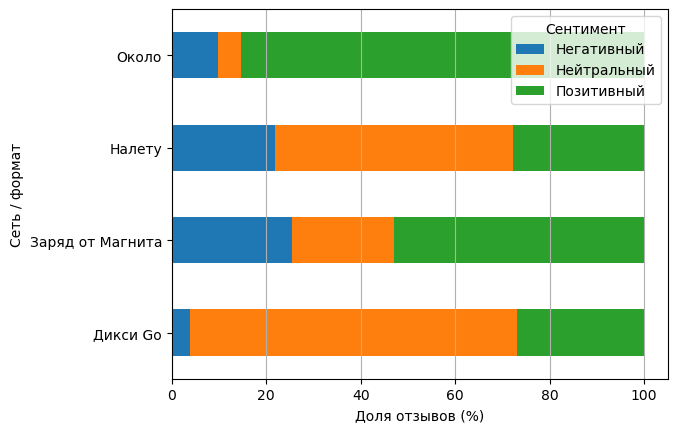

In [23]:
sentiment_by_all = pd.crosstab(df['Сеть / формат'], df['Сентимент'], normalize='index').mul(100)

plt.figure(figsize=(8, 4))
sentiment_by_all.plot(kind='barh', stacked=True)
plt.xlabel('Доля отзывов (%)')
plt.grid(axis = 'x')
plt.show()

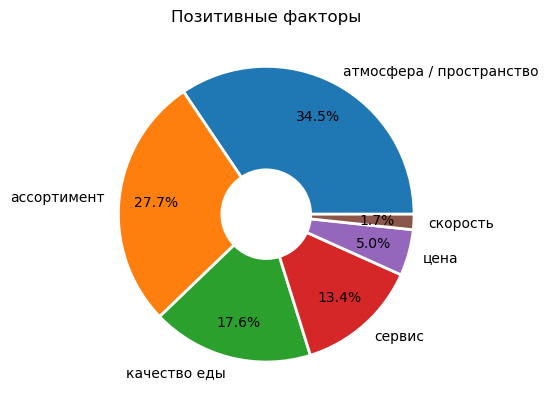

In [27]:
dop_df = pd.DataFrame(driver_of_positive)
dop_df = dop_df.reset_index().melt(id_vars='Ключевая тема', var_name='proportion', value_name='Доля')

plt.pie(dop_df['Доля'], labels=dop_df['Ключевая тема'], autopct='%1.1f%%', pctdistance=0.75, wedgeprops=dict(width=0.7, edgecolor='white', linewidth=2))
plt.title('Позитивные факторы')
plt.show()

In [28]:
driver_of_negative

Ключевая тема
атмосфера / пространство    36.956522
скорость                    19.565217
ассортимент                 19.565217
цена                        10.869565
сервис                       8.695652
качество еды                 4.347826
Name: proportion, dtype: float64

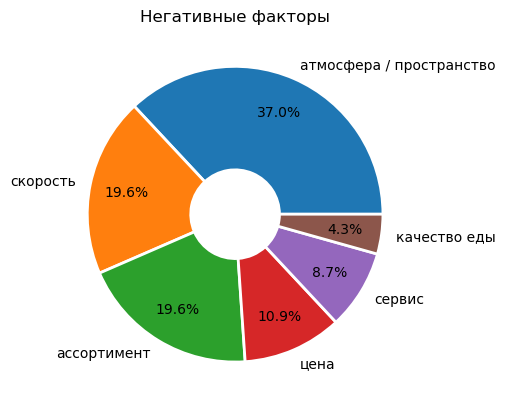

In [29]:
don_df = pd.DataFrame(driver_of_negative)
don_df = don_df.reset_index().melt(id_vars='Ключевая тема', var_name='proportion', value_name='Доля')

plt.pie(don_df['Доля'], labels=don_df['Ключевая тема'], autopct='%1.1f%%', pctdistance=0.75, wedgeprops=dict(width=0.7, edgecolor='white', linewidth=2))
plt.title('Негативные факторы')
plt.show()

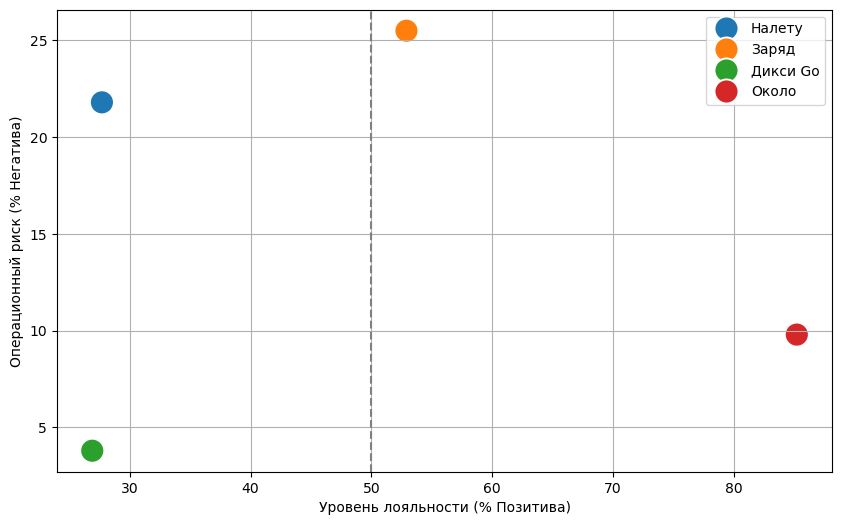

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=[27.7, 52.9, 26.9, 85.2], y=[21.8, 25.5, 3.8, 9.8], hue=['Налету', 'Заряд', 'Дикси Go', 'Около'], s=300)
plt.axvline(50, color='gray', linestyle='--') 
plt.xlabel('Уровень лояльности (% Позитива)')
plt.ylabel('Операционный риск (% Негатива)')
plt.grid()
plt.show()

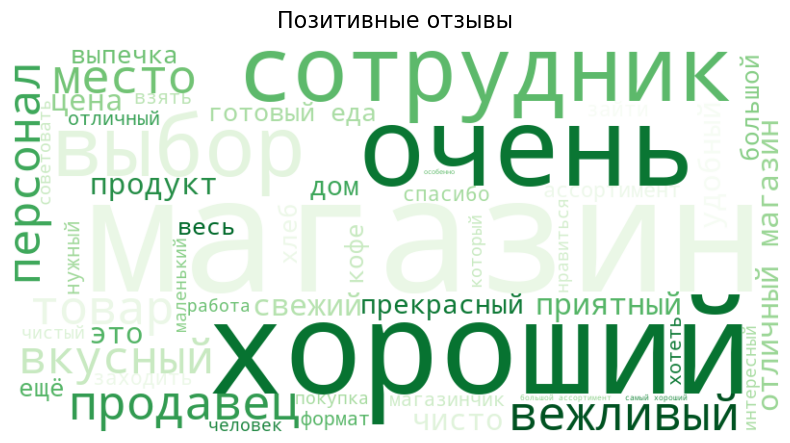

In [31]:
pos_cloud = ' '.join(df[df['Сентимент'] == 'Позитивный']['clean_text'].astype(str))

wc_pos = WordCloud(width=800, height=400, background_color='white', max_words=50, stopwords=russian_stopwords, colormap = 'Greens_r').generate(pos_cloud)

plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Позитивные отзывы', fontsize=16, pad=15)
plt.show()

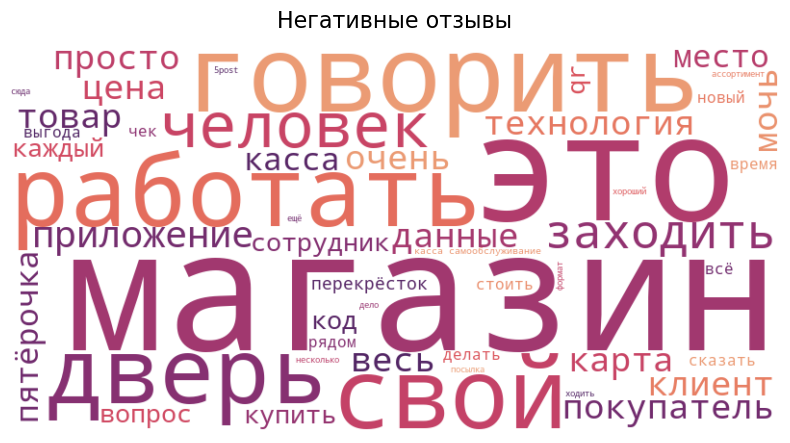

In [32]:
neg_cloud = ' '.join(df[df['Сентимент'] == 'Негативный']['clean_text'].astype(str))

wc_neg = WordCloud(width=800, height=400, background_color='white', max_words=50, stopwords=russian_stopwords, colormap='flare').generate(neg_cloud)

plt.figure(figsize=(10, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Негативные отзывы', fontsize=16, pad=15)
plt.show()